Code without Weighted Trainers

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# import numpy as np
# import pandas as pd
# from PIL import Image

# from datasets import Dataset

# from transformers import (
#     AutoImageProcessor,
#     AutoModelForImageClassification,
#     TrainingArguments,
#     Trainer
# )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# data_path = "/content/drive/MyDrive/DementiaNetProject/data"

# train_df = pd.read_csv(f"{data_path}/train_img.csv", sep="\t")
# valid_df = pd.read_csv(f"{data_path}/valid_img.csv", sep="\t")

# print(train_df.head())
# print(valid_df.head())
# print(train_df.columns)

                      file       label  \
0  DonaldSutherland_3_seg4  nodementia   
1   RobertAnderson_10_seg6    dementia   
2   AnthonyHopkins_2_seg11  nodementia   
3     woodydurham_0_2_seg2    dementia   
4    MartinScorsese_2_seg4  nodementia   

                                                path  
0  /content/drive/MyDrive/DementiaNetProject/data...  
1  /content/drive/MyDrive/DementiaNetProject/data...  
2  /content/drive/MyDrive/DementiaNetProject/data...  
3  /content/drive/MyDrive/DementiaNetProject/data...  
4  /content/drive/MyDrive/DementiaNetProject/data...  
                    file       label  \
0        AlPacino_3_seg3  nodementia   
1  mauricehinchey_5_seg0    dementia   
2   Chuck norris_3_seg12  nodementia   
3    BrianDePalma_1_seg7  nodementia   
4     KennyRogers_1_seg1  nodementia   

                                                path  
0  /content/drive/MyDrive/DementiaNetProject/data...  
1  /content/drive/MyDrive/DementiaNetProject/data...  
2  /content

In [ ]:
# label_list = sorted(train_df["label"].unique())

# label2id = {l: i for i, l in enumerate(label_list)}
# id2label = {i: l for l, i in label2id.items()}

# num_classes = len(label_list)

# print("Classes:", label_list)

Classes: ['dementia', 'nodementia']


In [ ]:
# train_data = Dataset.from_pandas(train_df)
# valid_data = Dataset.from_pandas(valid_df)

In [ ]:
# model_name = "microsoft/resnet-18"

# processor = AutoImageProcessor.from_pretrained(model_name)

# model = AutoModelForImageClassification.from_pretrained(
#     model_name,
#     num_labels=num_classes,
#     id2label=id2label,
#     label2id=label2id,
#     ignore_mismatched_sizes=True
# )

#     # Freeze everything
# for param in model.base_model.parameters():
#     param.requires_grad = False

# # Only unfreeze the last residual block
# for name, param in model.base_model.named_parameters():
#     if "layer4" in name:
#         param.requires_grad = True

# # Always train classifier head
# for param in model.classifier.parameters():
#     param.requires_grad = True

Loading weights:   0%|          | 0/122 [00:00<?, ?it/s]

ResNetForImageClassification LOAD REPORT from: microsoft/resnet-18
Key                 | Status   |                                                                                        
--------------------+----------+----------------------------------------------------------------------------------------
classifier.1.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 512]) vs model:torch.Size([2, 512])
classifier.1.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
# def preprocess(batch):
#     images = [Image.open(p).convert("RGB") for p in batch["path"]]

#     inputs = processor(images=images)
#     inputs["labels"] = [label2id[l] for l in batch["label"]]

#     return inputs

In [ ]:
# train_data = train_data.map(
#     preprocess,
#     batched=True,
#     remove_columns=train_data.column_names
# )

# valid_data = valid_data.map(
#     preprocess,
#     batched=True,
#     remove_columns=valid_data.column_names
# )

Map:   0%|          | 0/3041 [00:00<?, ? examples/s]

Map:   0%|          | 0/761 [00:00<?, ? examples/s]

In [ ]:
# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     preds = np.argmax(logits, axis=1)
#     acc = (preds == labels).mean()
#     return {"accuracy": acc}

##**Parameters for Training:**

In [ ]:
# from torchvision import transforms

# augment = transforms.Compose([
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomVerticalFlip(),
#     transforms.RandomRotation(15),
#     transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
#     transforms.RandomGrayscale(p=0.1),
#     transforms.RandomResizedCrop(size=224, scale=(0.8, 1.0)),
# ])

In [ ]:
# training_args = TrainingArguments(
#     output_dir="/content/drive/MyDrive/DementiaNetProject/resnet_model",
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     load_best_model_at_end=True,
#     metric_for_best_model="accuracy",
#     greater_is_better=True,

#     learning_rate=5e-4,       # higher LR is fine when fewer layers are trainable
#     weight_decay=0.05,        # stronger regularization for small dataset
#     num_train_epochs=30,      # more epochs, but early stopping will save you
#     warmup_ratio=0.1,
#     lr_scheduler_type="cosine",

#     per_device_train_batch_size=16,   # smaller batch = more gradient updates per epoch
#     per_device_eval_batch_size=16,

#     logging_strategy="epoch",
#     fp16=True,
#     save_total_limit=2,
# )

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
# import numpy as np
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     preds = np.argmax(logits, axis=1)

#     acc = accuracy_score(labels, preds)
#     precision = precision_score(labels, preds, zero_division=0)
#     recall = recall_score(labels, preds, zero_division=0)
#     f1 = f1_score(labels, preds, zero_division=0)

#     return {
#         "accuracy": acc,
#         "precision": precision,
#         "recall": recall,
#         "f1": f1
#     }

In [ ]:
# from transformers import EarlyStoppingCallback

# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_data,
#     eval_dataset=valid_data,
#     compute_metrics=compute_metrics,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
# )

In [ ]:
# trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.684252,0.676755,0.601840,0.622695,0.922269,0.743438
2,0.662196,0.667831,0.626807,0.630790,0.972689,0.765289
3,0.639281,0.688476,0.545335,0.674731,0.527311,0.591981
4,0.630501,0.651588,0.620237,0.670310,0.773109,0.718049
5,0.618740,0.638365,0.646518,0.677530,0.829832,0.745987
6,0.602588,0.675417,0.655716,0.651989,0.964286,0.777966
7,0.608646,0.650126,0.643890,0.666667,0.861345,0.751604
8,0.598607,0.685607,0.592641,0.724324,0.563025,0.633570
9,0.597585,0.641264,0.636005,0.677996,0.796218,0.732367
10,0.596920,0.646560,0.634691,0.679348,0.787815,0.729572


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2101, training_loss=0.6214418915099953, metrics={'train_runtime': 9622.0643, 'train_samples_per_second': 9.481, 'train_steps_per_second': 0.596, 'total_flos': 3.376943559154852e+17, 'train_loss': 0.6214418915099953, 'epoch': 11.0})

In [ ]:
# trainer.save_model("/content/drive/MyDrive/DementiaNetProject/resnet_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

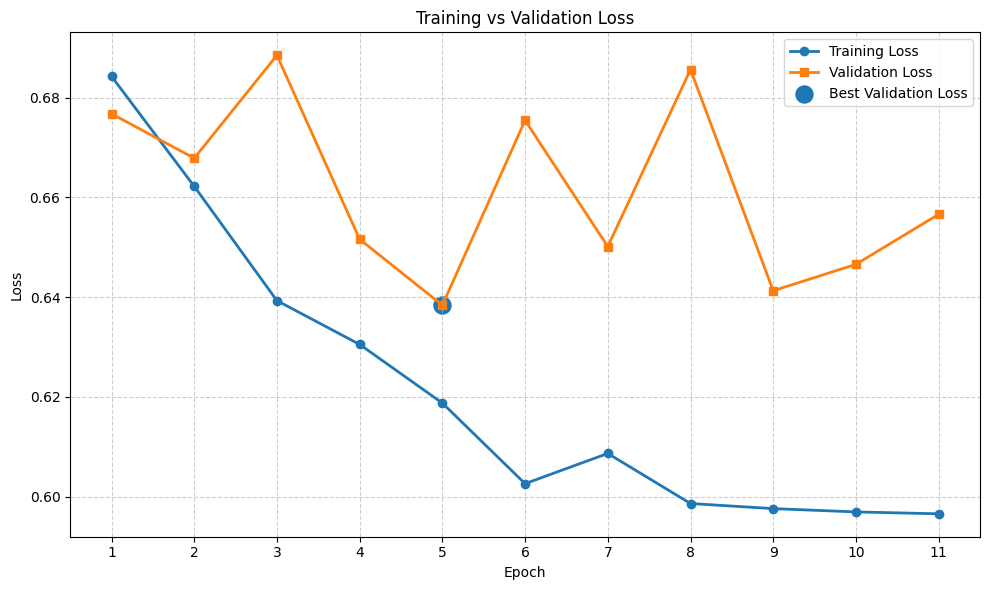

In [ ]:
# import matplotlib.pyplot as plt

# # Epochs
# epochs = list(range(1, 12))

# # Training loss
# train_loss = [
#     0.684252,
#     0.662196,
#     0.639281,
#     0.630501,
#     0.618740,
#     0.602588,
#     0.608646,
#     0.598607,
#     0.597585,
#     0.596920,
#     0.596546
# ]

# # Validation loss
# val_loss = [
#     0.676755,
#     0.667831,
#     0.688476,
#     0.651588,
#     0.638365,
#     0.675417,
#     0.650126,
#     0.685607,
#     0.641264,
#     0.646560,
#     0.656589
# ]

# # Plot
# plt.figure(figsize=(10,6))

# plt.plot(epochs, train_loss, marker='o', linewidth=2, label='Training Loss')
# plt.plot(epochs, val_loss, marker='s', linewidth=2, label='Validation Loss')

# # Highlight best validation loss
# best_epoch = 5
# best_val = 0.638365
# plt.scatter(best_epoch, best_val, s=150, label='Best Validation Loss')

# plt.title("Training vs Validation Loss")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.xticks(epochs)
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.legend()
# plt.tight_layout()

# plt.show()

Initial Run: around 1 hr 20 min

New Version with Weighted Trainers to Reduce False Negatives





In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
from PIL import Image
from datasets import Dataset
from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
import torch
import torch.nn as nn
from torchvision import transforms
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

data_path = "/content/drive/MyDrive/DementiaNetProject/data"
train_df = pd.read_csv(f"{data_path}/train_img.csv", sep="\t")
valid_df = pd.read_csv(f"{data_path}/valid_img.csv", sep="\t")

label_list = sorted(train_df["label"].unique())
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}
num_classes = len(label_list)

print("Classes:", label_list)
print("label2id:", label2id)  # confirm which index is dementia
print(train_df["label"].value_counts())
print(valid_df["label"].value_counts())

Mounted at /content/drive
Classes: ['dementia', 'nodementia']
label2id: {'dementia': 0, 'nodementia': 1}
label
nodementia    1902
dementia      1139
Name: count, dtype: int64
label
nodementia    476
dementia      285
Name: count, dtype: int64


In [ ]:
model_name = "microsoft/resnet-18"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# Freeze everything
for param in model.base_model.parameters():
    param.requires_grad = False

# Unfreeze layer4 only — matched what was working before
for name, param in model.base_model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

The image processor of type `ConvNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/122 [00:00<?, ?it/s]

ResNetForImageClassification LOAD REPORT from: microsoft/resnet-18
Key                 | Status   |                                                                                        
--------------------+----------+----------------------------------------------------------------------------------------
classifier.1.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.1.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 512]) vs model:torch.Size([2, 512])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Trainable: 1,026 / 11,177,538


In [ ]:
augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomResizedCrop(size=224, scale=(0.8, 1.0)),
])

def preprocess(batch, augment_images=False):
    images = [Image.open(p).convert("RGB") for p in batch["path"]]
    if augment_images:
        images = [augment(img) for img in images]
    inputs = processor(images=images)
    inputs["labels"] = [label2id[l] for l in batch["label"]]
    return inputs

# Re-create from pandas to ensure path column exists
train_data = Dataset.from_pandas(train_df)
valid_data = Dataset.from_pandas(valid_df)

train_data = train_data.map(
    lambda b: preprocess(b, augment_images=True),
    batched=True,
    remove_columns=train_data.column_names
)
valid_data = valid_data.map(
    lambda b: preprocess(b, augment_images=False),
    batched=True,
    remove_columns=valid_data.column_names
)

print("Train size:", len(train_data))
print("Valid size:", len(valid_data))

Map:   0%|          | 0/3041 [00:00<?, ? examples/s]

Map:   0%|          | 0/761 [00:00<?, ? examples/s]

Train size: 3041
Valid size: 761


In [ ]:
# Heavily penalize missing dementia cases
# Find dementia index first
dementia_idx = label2id["dementia"]
nodementia_idx = label2id["nodementia"]

# Manual asymmetric weights: dementia gets 3x penalty
# This directly reduces false negatives
class_weights = torch.zeros(num_classes)
class_weights[dementia_idx] = 3.0
class_weights[nodementia_idx] = 1.0
print("Class weights:", class_weights)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(
            weight=class_weights.to(outputs.logits.device)
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

Class weights: tensor([3., 1.])


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()

    acc = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    # Count actual false negatives so you can track directly
    dementia_idx = label2id["dementia"]
    fn = int(((preds != dementia_idx) & (labels == dementia_idx)).sum())

    try:
        auc = roc_auc_score(labels, probs[:, dementia_idx])
    except ValueError:
        auc = 0.0

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "false_negatives": fn   # track this directly each epoch
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/DementiaNetProject/resnet_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="recall",   # optimize for recall — directly targets FN reduction
    greater_is_better=True,
    learning_rate=5e-4,
    weight_decay=0.05,
    num_train_epochs=30,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_strategy="epoch",
    fp16=True,
    save_total_limit=2,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=valid_data,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

trainer.train()
trainer.save_model("/content/drive/MyDrive/DementiaNetProject/resnet_model")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc,False Negatives
1,0.692490,0.678714,0.402102,0.723404,0.071429,0.130019,0.467758,13
2,0.680903,0.661881,0.490145,0.713592,0.308824,0.431085,0.419446,59
3,0.666186,0.681809,0.390276,0.833333,0.031513,0.060729,0.433075,3
4,0.657828,0.655815,0.421813,0.800000,0.100840,0.179104,0.403321,12
5,0.642828,0.648607,0.520368,0.728395,0.371849,0.492350,0.389518,66
6,0.641173,0.655668,0.563732,0.713018,0.506303,0.592138,0.378892,97
7,0.631322,0.655305,0.517740,0.705660,0.392857,0.504723,0.399701,78
8,0.637829,0.695538,0.392904,0.769231,0.042017,0.079681,0.408669,6
9,0.634248,0.649284,0.532194,0.765487,0.363445,0.492877,0.391530,53
10,0.628931,0.646317,0.486202,0.785235,0.245798,0.374400,0.386149,32


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]